In [86]:
import pdfplumber
from PIL import Image
import uuid
import re
import sys
import os
import pandas as pd

# Nimmt den aktuellen Ordner als Basis
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from models import MietspiegelGrid


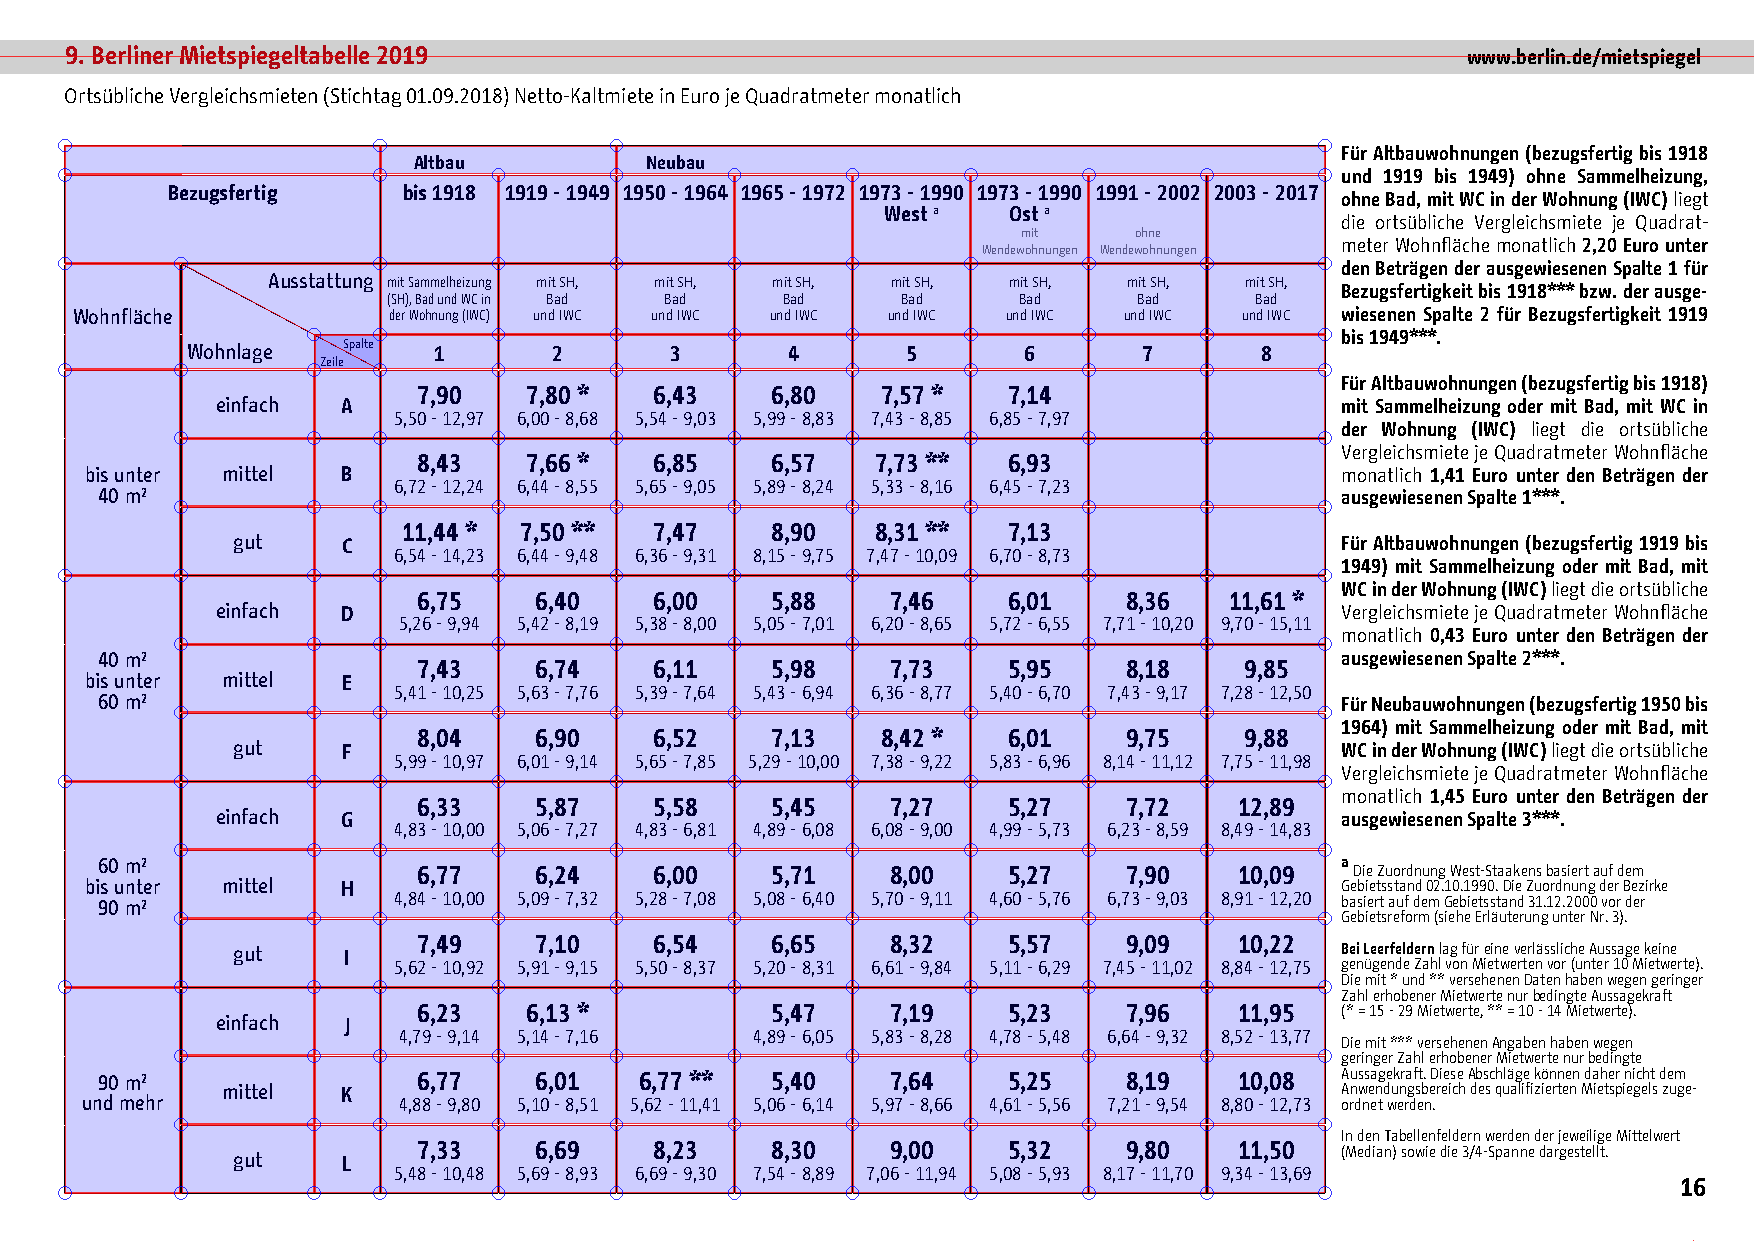

In [142]:

pdf_path = "../data/berlin/872.pdf"

with pdfplumber.open(pdf_path) as pdf:
    # Let's look at page 2 (index 1), which is usually where tables start breaking across pages
    page = pdf.pages[16] 
    
    # Render the page as an image and draw the detected table bounding boxes
    im = page.to_image(resolution=150)
    im.reset().debug_tablefinder()
    
    # If you are in a notebook, this will display the image right below the cell
    display(im.annotated)

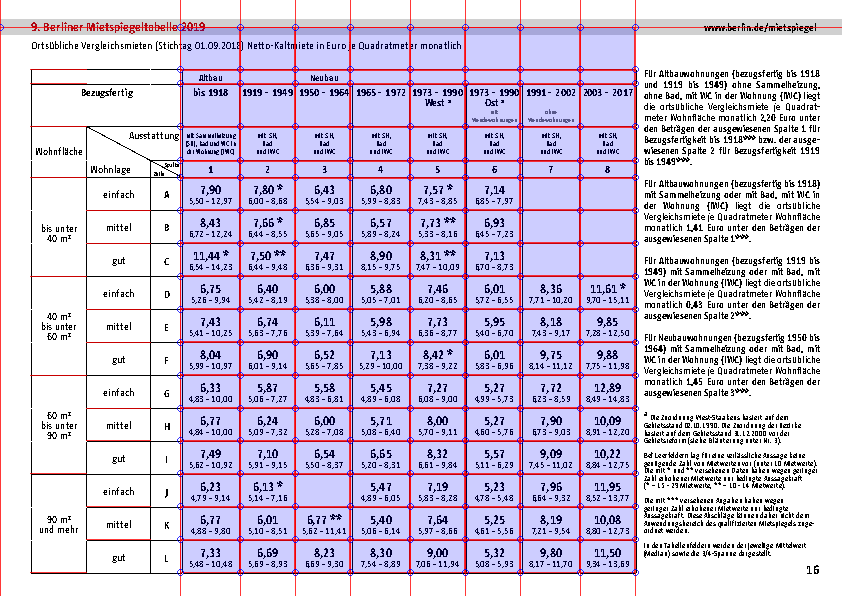

In [157]:

estimated_v_lines = [
    0,    # Far left edge of the table
    180,   # Divider before "Wohnlage" (starts at 363)
    240,   # Divider before "Spalte" (starts at 624)
    295,   # Divider before "Baujahr" (starts at 885)
    350,   # Divider before "Mietpreis" (starts at 1146)
    410,   # Divider before "Wohnlage" (starts at 1407)
    465,   # Divider before "Spalte" (starts at 1668)
    520,   # Divider before "Baujahr" (starts at 1929
    580,   # Divider before "Mietpreis" (starts at 2190)
    635,   # Divider before "Wohnlage" (starts at 2451)

]

custom_settings = {
    "horizontal_strategy": "lines", 
    "intersection_y_tolerance": 10, 
    "vertical_strategy": "explicit", 
    "explicit_vertical_lines": estimated_v_lines,
}

with pdfplumber.open(pdf_path) as pdf:
    # ADD THIS LINE: Grab the first page of the PDF!
    page = pdf.pages[16] 
    
    # Now you can filter the page
    page_with_lines = page.filter(lambda obj: obj["object_type"] in ["char", "line", "rect"])
    
    im = page_with_lines.to_image()
    im.reset().debug_tablefinder(custom_settings)
    
    # Assuming you are in a Jupyter Notebook, display the image
    display(im.annotated)

In [158]:
with pdfplumber.open(pdf_path) as pdf:
    # ADD THIS LINE: Grab the first page of the PDF!
    
    # Now you can filter the page
    page_with_lines = page.filter(lambda obj: obj["object_type"] in ["char", "line", "rect"])
    
    #im = page_with_lines.to_image()
    #im.reset().debug_tablefinder(custom_settings)
    
    # Assuming you are in a Jupyter Notebook, display the image
    #display(im.annotated)
    extracted_table = page_with_lines.extract_table(table_settings=custom_settings)
    
    if extracted_table:
        # Load it into a DataFrame for a nice HTML table view
        df = pd.DataFrame(extracted_table)
        
        # Clean up any messy newline characters inside the cells
        df = df.replace('\n', ' ', regex=True)
        
        display(df)
    else:
        print("No table could be extracted. Check your coordinates!")

,0,1,2,3,4,5,6,7
0,2019 tag 01.09.2018,) Netto-Kaltm,iete in Euro j,e Quadratmet,er monatlich,,,
1,Altbau,,Neubau,,,,,
2,bis 1918,1919 - 1949,1950 - 1964,1965 - 1972,1973 - 1990 West a,1973 - 1990 Ost a mit Wendewohnungen,1991 - 2002 ohne Wendewohnungen,2003 - 2017
3,"mit Sammelheizung (SH), Bad und WC in der Wohn...","mit SH, Bad und IWC","mit SH, Bad und IWC","mit SH, Bad und IWC","mit SH, Bad und IWC","mit SH, Bad und IWC","mit SH, Bad und IWC","mit SH, Bad und IWC"
4,1,2,3,4,5,6,7,8
5,"7,90 5,50 - 12,97","7,80 * 6,00 - 8,68","6,43 5,54 - 9,03","6,80 5,99 - 8,83","7,57 * 7,43 - 8,85","7,14 6,85 - 7,97",,
6,"8,43 6,72 - 12,24","7,66 * 6,44 - 8,55","6,85 5,65 - 9,05","6,57 5,89 - 8,24","7,73 ** 5,33 - 8,16","6,93 6,45 - 7,23",,
7,"11,44 * 6,54 - 14,23","7,50 ** 6,44 - 9,48","7,47 6,36 - 9,31","8,90 8,15 - 9,75","8,31 ** 7,47 - 10,09","7,13 6,70 - 8,73",,
8,"6,75 5,26 - 9,94","6,40 5,42 - 8,19","6,00 5,38 - 8,00","5,88 5,05 - 7,01","7,46 6,20 - 8,65","6,01 5,72 - 6,55","8,36 7,71 - 10,20","11,61 * 9,70 - 15,11"
9,"7,43 5,41 - 10,25","6,74 5,63 - 7,76","6,11 5,39 - 7,64","5,98 5,43 - 6,94","7,73 6,36 - 8,77","5,95 5,40 - 6,70","8,18 7,43 - 9,17","9,85 7,28 - 12,50"


In [159]:
# Map the Column Index to Building Years and Location Flags
COL_MAPPING = {
    0: {"min": 0,    "max": 1918, "flag": "ALL"},
    1: {"min": 1919, "max": 1949, "flag": "ALL"},
    2: {"min": 1950, "max": 1964, "flag": "ALL"},
    3: {"min": 1965, "max": 1972, "flag": "ALL"},
    4: {"min": 1973, "max": 1990, "flag": "West"}, # Column 4 is West
    5: {"min": 1973, "max": 1990, "flag": "Ost"},  # Column 5 is East
    6: {"min": 1991, "max": 2002, "flag": "ALL"},
    7: {"min": 2003, "max": 2017, "flag": "ALL"},
}

# Map the Row Index to Size Brackets and Wohnlage
ROW_MAPPING = {
    # < 40 sqm
    5: {"size_lower": 0.0,  "size_upper": 39.99, "wohnlage": "low"},
    6: {"size_lower": 0.0,  "size_upper": 39.99, "wohnlage": "mid"},
    7: {"size_lower": 0.0,  "size_upper": 39.99, "wohnlage": "good"},
    # 40 - 59.99 sqm
    8: {"size_lower": 40.0, "size_upper": 59.99, "wohnlage": "low"},
    9: {"size_lower": 40.0, "size_upper": 59.99, "wohnlage": "mid"},
    10: {"size_lower": 40.0, "size_upper": 59.99, "wohnlage": "good"},
    # 60 - 89.99 sqm
    11: {"size_lower": 60.0, "size_upper": 89.99, "wohnlage": "low"},
    12: {"size_lower": 60.0, "size_upper": 89.99, "wohnlage": "mid"},
    13: {"size_lower": 60.0, "size_upper": 89.99, "wohnlage": "good"},
    # 90+ sqm
    14: {"size_lower": 90.0, "size_upper": 9999.0, "wohnlage": "low"},
    15: {"size_lower": 90.0, "size_upper": 9999.0, "wohnlage": "mid"},
    16: {"size_lower": 90.0, "size_upper": 9999.0, "wohnlage": "good"},
}

In [160]:
def parse_rent_cell(cell_str: str):
    """
    Takes a string like '8,42 \n 5,86 - 13,82' or '8,42 5,86 - 13,82'
    and returns (avg, min, max) as floats.
    """
    if not cell_str or str(cell_str).strip() == "" or cell_str is None:
        return None
    
    # Replace German decimal commas with periods
    cleaned = str(cell_str).replace(",", ".")
    
    # Extract all decimal numbers using regex
    numbers = re.findall(r"[\d\.]+", cleaned)
    
    # We expect exactly 3 numbers: Avg, Min, Max
    if len(numbers) >= 3:
        return {
            "avg": float(numbers[0]),
            "min": float(numbers[1]),
            "max": float(numbers[2])
        }
    return None

# --- 4. Main Processing Loop ---

# Generate a mock UUID for the catalog_id
catalog_uuid = uuid.uuid4()
parsed_grid_items = []

# Assuming 'extracted_table' is the list of lists output from pdfplumber
# We iterate only through the data rows (4 through 15)
for row_idx in range(5, 16):
    row_data = extracted_table[row_idx]
    
    # Look up the size and wohnlage for this specific row
    row_meta = ROW_MAPPING[row_idx]
    
    # Iterate through the 8 data columns
    for col_idx in range(8):
        cell_value = row_data[col_idx]
        
        # Look up the years and location flag for this column
        col_meta = COL_MAPPING[col_idx]
        
        # Parse the text into numbers
        rent_data = parse_rent_cell(cell_value)
        
        # If the cell wasn't empty, create our Pydantic object
        if rent_data:
            grid_item = MietspiegelGrid(
                catalog_id=catalog_uuid,
                wohnlage=row_meta["wohnlage"],
                buildingyear_min=col_meta["min"],
                buildingyear_max=col_meta["max"],
                size_lower=row_meta["size_lower"],
                size_upper=row_meta["size_upper"],
                rent_sqm_min=rent_data["min"],
                rent_sqm_avg=rent_data["avg"],
                rent_sqm_max=rent_data["max"],
                location_flag=col_meta["flag"]
            )
            parsed_grid_items.append(grid_item)

# Let's print the first 3 parsed objects to verify!
print(f"Successfully parsed {len(parsed_grid_items)} grid records.\n")
for item in parsed_grid_items[:3]:
    print(item.model_dump_json(indent=2))

Successfully parsed 81 grid records.

{
  "catalog_id": "d700faf0-bcb0-4b34-8fc0-efe51a4b11b6",
  "wohnlage": "low",
  "equipment_level": null,
  "buildingyear_min": 0,
  "buildingyear_max": 1918,
  "size_lower": 0.0,
  "size_upper": 39.99,
  "rent_sqm_min": 5.5,
  "rent_sqm_avg": 7.9,
  "rent_sqm_max": 12.97,
  "location_flag": "ALL"
}
{
  "catalog_id": "d700faf0-bcb0-4b34-8fc0-efe51a4b11b6",
  "wohnlage": "low",
  "equipment_level": null,
  "buildingyear_min": 1919,
  "buildingyear_max": 1949,
  "size_lower": 0.0,
  "size_upper": 39.99,
  "rent_sqm_min": 6.0,
  "rent_sqm_avg": 7.8,
  "rent_sqm_max": 8.68,
  "location_flag": "ALL"
}
{
  "catalog_id": "d700faf0-bcb0-4b34-8fc0-efe51a4b11b6",
  "wohnlage": "low",
  "equipment_level": null,
  "buildingyear_min": 1950,
  "buildingyear_max": 1964,
  "size_lower": 0.0,
  "size_upper": 39.99,
  "rent_sqm_min": 5.54,
  "rent_sqm_avg": 6.43,
  "rent_sqm_max": 9.03,
  "location_flag": "ALL"
}


In [161]:
data_dicts = [item.model_dump() for item in parsed_grid_items]

# 2. Load into a Pandas DataFrame
df = pd.DataFrame(data_dicts)
df = df.drop(columns=['catalog_id'])

# [OPTIONAL] Drop the UUID column if you don't need it for your immediate CSV
# df = df.drop(columns=['catalog_id'])

# 3. Export directly to a CSV file
csv_filename = "../exports/ber_19_rent_grid.csv"
df.to_csv(csv_filename, index=False, encoding='utf-8')

print(f"Successfully exported {len(df)} rows to {csv_filename}!")

# Since you are in a notebook, let's render a quick preview of the final dataset
display(df.head())

Successfully exported 81 rows to ../exports/ber_19_rent_grid.csv!


,wohnlage,equipment_level,buildingyear_min,buildingyear_max,size_lower,size_upper,rent_sqm_min,rent_sqm_avg,rent_sqm_max,location_flag
0,low,None,0,1918,0.0,39.99,5.50,7.90,12.97,ALL
1,low,None,1919,1949,0.0,39.99,6.00,7.80,8.68,ALL
2,low,None,1950,1964,0.0,39.99,5.54,6.43,9.03,ALL
3,low,None,1965,1972,0.0,39.99,5.99,6.80,8.83,ALL
4,low,None,1973,1990,0.0,39.99,7.43,7.57,8.85,West
